# Macro-Mode behind Factor Model in Chinese A-Shares market

Extending from various Random Matrix Theories (MP-Law, BBP Phase-transition, etc.) researched previously, now we take a look at real-world equity-market, jumping out of clean and idealized system we worked on before. In following experiment, we will use Chinese A-Shares as the example, exploring if principal components can offer market-insightful information to us.

## Introduction

In any mature markets, there's obviously no clear DGP pattern. What we do is to model market's DGP, i.e. equity returns, as a multi-factor generating process. We're sure that the model is inaccurate, but that's not what to pursue. The thing we do know is market is driven by various explicit and implicit factors, e.g. policies, industries, insider-news etc. So, over certain time-interval, we approximates market's DGP as a multi-factor model embedded with noises, in form: $a_t = \sum_{i=1}^k f_{ti} * l_i + e_t$. Here we assume loading-vectors $l_1, \dots, l_k$ are fixed in model, suggesting model is only effective in a short time-interval. 

An important thing here is: We're not applying PCA on covariance return-matrix, but on correlation return-matrix. As for covariance-matrix, principal components will be led by high-volatility stocks, making principal components' information wrongly dominated by high-volatility stocks, see experiments in notebook "Why Correlation PCA". So, we are actually modeling the **standardized (adjusted-log) return-matrix** with multi-factor model assumpptions stated above, and RMT-regime together with BBP Phase-transition shows principal components are likely to recover back real-loading direciton if the factor is strong enough.

## Empirical Design: Rolling PCA on CSI 500 Regimes

We now test the same PCA/RMT idea on real A-share data. The goal is not to claim that the market has an exact low-rank DGP, but to ask whether rolling principal components carry interpretable market and sector information under two different regimes.

We use Tushare data with a fixed CSI 500 stock pool and SW2021 first-level industry labels. In every rolling window, returns are standardized stock-by-stock and PCA is applied to the sample correlation matrix.

Main questions:

- **PC1 market mode:** does PC1 explain a large share of standardized variance, and do most stocks load with the same sign?
- **RMT benchmark:** how many sample eigenvalues escape the Marchenko--Pastur upper edge?
- **PC2/PC3 sector mode:** for each window, which SW2021 first-level industry carries the largest squared-loading mass of PC2/PC3?


### Data Choices

We study two indicative regimes:

- **Property stress regime:** 2021-11-01 to 2022-10-31.
- **Technology/dividend regime:** 2025-06-30 to 2026-03-31.

The stock pool is fixed. We take the intersection of CSI 500 constituents near the beginning of the two regimes, then keep stocks with sufficient adjusted-close coverage in both regimes. This makes regime comparison cleaner: changes in PCA structure come from return behavior, not from changing the stock universe.

Price construction:

- fetch `daily` close prices and `adj_factor` from Tushare;
- construct adjusted close as `close * adj_factor / last_adj_factor` inside each regime;
- compute log returns;
- standardize each stock within each rolling window before PCA.


In [1]:
from pathlib import Path
import os
import time
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib_cache").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

CACHE_DIR = Path("data_cache/tushare_a_share_pca")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

INDEX_CODE = "000905.SH"  # CSI 500
REGIMES = {
    "Property stress": ("20211101", "20221031"),
    "Tech/dividend": ("20250630", "20260331"),
}
SNAPSHOT_DATES = {
    "Property stress": "20211029",
    "Tech/dividend": "20250630",
}

WINDOW = 126
STEP = 14
MIN_REGIME_COVERAGE = 0.95
RETURN_CLIP = 0.20
TOP_STOCKS = 20
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)


### Tushare Connection

This notebook reads the Tushare token from the local environment variable `TUSHARE_TOKEN`. Do not hard-code private tokens in notebooks before uploading to GitHub.


In [ ]:
import tushare as ts

TUSHARE_TOKEN = os.getenv("TUSHARE_TOKEN", "")
if not TUSHARE_TOKEN:
    raise ValueError("Set the TUSHARE_TOKEN environment variable before running this notebook.")

ts.set_token(TUSHARE_TOKEN)
pro = ts.pro_api()


### Helper Functions

All downloaded data are cached locally. The first run will call Tushare APIs; later runs should reuse CSV files.


In [3]:
def cache_path(name: str) -> Path:
    return CACHE_DIR / name


def read_or_fetch_csv(path: Path, fetch_fn, **read_kwargs) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path, **read_kwargs)
    df = fetch_fn()
    df.to_csv(path, index=False)
    return df


def latest_index_weight_snapshot(index_code: str, snapshot_date: str) -> pd.DataFrame:
    end = pd.to_datetime(snapshot_date)
    start = (end - pd.Timedelta(days=45)).strftime("%Y%m%d")
    end_str = end.strftime("%Y%m%d")
    path = cache_path(f"index_weight_{index_code}_{start}_{end_str}.csv")

    def _fetch():
        return pro.index_weight(index_code=index_code, start_date=start, end_date=end_str)

    df = read_or_fetch_csv(path, _fetch, dtype={"trade_date": str})
    if df.empty:
        raise ValueError(f"No index_weight data for {index_code}, {start}-{end_str}.")
    df["trade_date"] = df["trade_date"].astype(str)
    latest = df["trade_date"].max()
    snap = df.loc[df["trade_date"] == latest, ["index_code", "con_code", "trade_date", "weight"]].copy()
    return snap.rename(columns={"con_code": "ts_code"})


def fetch_sw2021_l1_map() -> pd.DataFrame:
    path = cache_path("sw2021_l1_member_map.csv")
    if path.exists():
        return pd.read_csv(path, dtype={"ts_code": str})

    l1 = pro.index_classify(level="L1", src="SW2021")
    frames = []
    for _, row in l1.iterrows():
        l1_code = row["index_code"]
        l1_name = row["industry_name"]
        members = pro.index_member_all(l1_code=l1_code, is_new="Y")
        if not members.empty:
            members = members.copy()
            if "l1_name" not in members.columns:
                members["l1_name"] = l1_name
            if "l1_code" not in members.columns:
                members["l1_code"] = l1_code
            frames.append(members)
        time.sleep(0.08)

    out = pd.concat(frames, ignore_index=True)
    keep_cols = [c for c in ["ts_code", "name", "l1_code", "l1_name", "l2_name", "l3_name"] if c in out.columns]
    out = out[keep_cols].dropna(subset=["ts_code", "l1_name"]).drop_duplicates(subset=["ts_code"])
    out.to_csv(path, index=False)
    return out


### Fixed CSI 500 Universe with SW2021 Labels

We take the intersection of CSI 500 constituents from the two regime-start snapshots and attach SW2021 first-level industry labels.


In [4]:
snapshots = {name: latest_index_weight_snapshot(INDEX_CODE, date) for name, date in SNAPSHOT_DATES.items()}
for name, snap in snapshots.items():
    print(f"{name}: snapshot date {snap['trade_date'].iloc[0]}, constituents {snap['ts_code'].nunique()}")

common_universe = sorted(set.intersection(*(set(snap["ts_code"]) for snap in snapshots.values())))
print(f"CSI 500 snapshot intersection size: {len(common_universe)}")

# Average available index weights across the two snapshots for later ordering/diagnostics.
weight_table = pd.concat([
    snap.assign(snapshot=name) for name, snap in snapshots.items()
], ignore_index=True)
avg_weight = weight_table.groupby("ts_code")["weight"].mean().rename("avg_weight")

industry_map = fetch_sw2021_l1_map()
sector_map = industry_map.set_index("ts_code")["l1_name"]
name_map = industry_map.set_index("ts_code")["name"] if "name" in industry_map.columns else pd.Series(dtype=object)

universe = [code for code in common_universe if code in sector_map.index]
print(f"Universe with SW2021 L1 label: {len(universe)}")

universe_info = pd.DataFrame({"ts_code": universe})
universe_info["sector"] = universe_info["ts_code"].map(sector_map)
universe_info["name"] = universe_info["ts_code"].map(name_map)
universe_info["avg_weight"] = universe_info["ts_code"].map(avg_weight)
universe_info.sort_values("avg_weight", ascending=False).head(10)


Property stress: snapshot date 20211029, constituents 500
Tech/dividend: snapshot date 20250630, constituents 500
CSI 500 snapshot intersection size: 237
Universe with SW2021 L1 label: 237


,ts_code,sector,name,avg_weight
57,002340.SZ,电力设备,格林美,0.6320
92,300207.SZ,电力设备,欣旺达,0.6295
36,000988.SZ,机械设备,华工科技,0.5490
0,000009.SZ,电力设备,中国宝安,0.5340
173,600885.SH,电力设备,宏发股份,0.4825
172,600884.SH,电力设备,杉杉股份,0.4770
87,300037.SZ,电力设备,新宙邦,0.4500
183,600988.SH,有色金属,赤峰黄金,0.4315
221,603486.SH,家用电器,科沃斯,0.4005
47,002185.SZ,电子,华天科技,0.3980


### Adjusted Close and Log Returns

For each stock and regime, we merge `daily` and `adj_factor`, then construct adjusted close as

$$
P^{adj}_t = P^{close}_t \cdot \frac{AF_t}{AF_{last}}.
$$

Using adjusted close avoids artificial jumps caused by dividends, splits, and other corporate actions. We then compute log returns.


In [5]:
def fetch_daily_and_adj(ts_code: str, start_date: str, end_date: str) -> pd.DataFrame:
    path = cache_path(f"daily_adj_{ts_code}_{start_date}_{end_date}.csv")
    if path.exists():
        return pd.read_csv(path, dtype={"trade_date": str})

    daily = pro.daily(ts_code=ts_code, start_date=start_date, end_date=end_date)
    adj = pro.adj_factor(ts_code=ts_code, start_date=start_date, end_date=end_date)
    if daily.empty or adj.empty:
        out = pd.DataFrame(columns=["ts_code", "trade_date", "close", "adj_factor", "adj_close"])
    else:
        out = daily[["ts_code", "trade_date", "close"]].merge(adj, on=["ts_code", "trade_date"], how="inner")
        out = out.sort_values("trade_date")
        base = out["adj_factor"].iloc[-1]
        out["adj_close"] = out["close"] * out["adj_factor"] / base
    out.to_csv(path, index=False)
    time.sleep(0.08)
    return out


def build_adjusted_close_matrix(codes: list[str], start_date: str, end_date: str) -> pd.DataFrame:
    frames = []
    failed = []
    for i, ts_code in enumerate(codes, 1):
        try:
            df = fetch_daily_and_adj(ts_code, start_date, end_date)
            if not df.empty:
                tmp = df[["trade_date", "adj_close"]].copy()
                tmp["trade_date"] = pd.to_datetime(tmp["trade_date"])
                tmp = tmp.set_index("trade_date").rename(columns={"adj_close": ts_code})
                frames.append(tmp)
        except Exception as exc:
            failed.append((ts_code, str(exc)))
        if i % 50 == 0 or i == len(codes):
            print(f"Loaded {i}/{len(codes)} stocks for {start_date}-{end_date}")

    if failed:
        print(f"Failed stocks: {len(failed)}")
        print(failed[:10])
    if not frames:
        raise ValueError("No adjusted close data loaded.")
    close = pd.concat(frames, axis=1).sort_index()
    close = close.loc[~close.index.duplicated(keep="last")]
    return close


def returns_from_adjusted_close(close: pd.DataFrame) -> pd.DataFrame:
    ret = np.log(close).diff()
    if RETURN_CLIP is not None:
        ret = ret.clip(lower=-RETURN_CLIP, upper=RETURN_CLIP)
    return ret


In [6]:
adj_close_by_regime = {}
raw_returns_by_regime = {}

for regime_name, (start, end) in REGIMES.items():
    print(f"\nBuilding adjusted close for {regime_name}: {start}-{end}")
    adj_close = build_adjusted_close_matrix(universe, start, end)
    adj_close_by_regime[regime_name] = adj_close
    raw_returns_by_regime[regime_name] = returns_from_adjusted_close(adj_close)
    print(regime_name, "adjusted close shape", adj_close.shape)



Building adjusted close for Property stress: 20211101-20221031
Loaded 50/237 stocks for 20211101-20221031
Loaded 100/237 stocks for 20211101-20221031
Loaded 150/237 stocks for 20211101-20221031
Loaded 200/237 stocks for 20211101-20221031


Loaded 237/237 stocks for 20211101-20221031
Property stress adjusted close shape (243, 237)

Building adjusted close for Tech/dividend: 20250630-20260331


Loaded 50/237 stocks for 20250630-20260331
Loaded 100/237 stocks for 20250630-20260331
Loaded 150/237 stocks for 20250630-20260331
Loaded 200/237 stocks for 20250630-20260331
Loaded 237/237 stocks for 20250630-20260331
Tech/dividend adjusted close shape (183, 237)


### Coverage Filter

We keep the same fixed stock columns in both regimes. A stock is eligible if it has at least `MIN_REGIME_COVERAGE` valid returns in each regime.


In [7]:
eligible_sets = []
for name, ret in raw_returns_by_regime.items():
    coverage = ret.notna().mean(axis=0)
    eligible = set(coverage[coverage >= MIN_REGIME_COVERAGE].index)
    eligible_sets.append(eligible)
    print(f"{name}: eligible stocks before intersection = {len(eligible)}")

fixed_columns = sorted(set.intersection(*eligible_sets))
returns_by_regime = {
    name: ret[fixed_columns].dropna(axis=0, how="any")
    for name, ret in raw_returns_by_regime.items()
}

sector_final = sector_map.loc[fixed_columns]
name_final = name_map.reindex(fixed_columns).fillna("")

for name, ret in returns_by_regime.items():
    print(f"{name}: return matrix T x N = {ret.shape}, dates {ret.index.min().date()} to {ret.index.max().date()}")
print(f"Final fixed universe size N = {len(fixed_columns)}")

pd.DataFrame({
    "sector": sector_final,
    "name": name_final,
    "avg_weight": avg_weight.reindex(fixed_columns),
}).sort_values("avg_weight", ascending=False).head(10)


Property stress: eligible stocks before intersection = 235
Tech/dividend: eligible stocks before intersection = 231
Property stress: return matrix T x N = (184, 229), dates 2021-11-02 to 2022-10-31
Tech/dividend: return matrix T x N = (174, 229), dates 2025-07-01 to 2026-03-26
Final fixed universe size N = 229


,sector,name,avg_weight
ts_code,,,
002340.SZ,电力设备,格林美,0.6320
300207.SZ,电力设备,欣旺达,0.6295
000988.SZ,机械设备,华工科技,0.5490
000009.SZ,电力设备,中国宝安,0.5340
600885.SH,电力设备,宏发股份,0.4825
600884.SH,电力设备,杉杉股份,0.4770
300037.SZ,电力设备,新宙邦,0.4500
600988.SH,有色金属,赤峰黄金,0.4315
603486.SH,家用电器,科沃斯,0.4005


### Rolling PCA / RMT Functions

Inside each rolling window, returns are standardized column-by-column. We compute

$$
C = \frac{1}{T}X^\top X.
$$

Since each stock is standardized, `diag(C)=1` and `trace(C)=N`. Therefore, `lambda_1 / N` is PC1's explained variance ratio. If PC1 also has high sign coherence, it behaves like a market-wide common movement.


In [8]:
def pca_window(window_ret: pd.DataFrame) -> dict:
    mu = window_ret.mean(axis=0)
    sigma = window_ret.std(axis=0, ddof=0)
    good = sigma > 1e-12
    x_df = (window_ret.loc[:, good] - mu[good]) / sigma[good]
    x = x_df.to_numpy()
    T, N = x.shape

    corr = (x.T @ x) / T
    eigvals, eigvecs = np.linalg.eigh(corr)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    if eigvecs[:, 0].sum() < 0:
        eigvecs[:, 0] *= -1

    q = N / T
    lambda_plus = (1 + np.sqrt(q)) ** 2
    sign_coherence = max((eigvecs[:, 0] > 0).mean(), (eigvecs[:, 0] < 0).mean())

    return {
        "T": T,
        "N": N,
        "columns": x_df.columns,
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "lambda_plus": lambda_plus,
        "outlier_count": int((eigvals > lambda_plus).sum()),
        "lambda1_over_N": eigvals[0] / N,
        "pc1_sign_coherence": sign_coherence,
    }


def rolling_windows(regime_returns: pd.DataFrame, window: int = WINDOW, step: int = STEP):
    dates = regime_returns.index
    if len(dates) < window:
        raise ValueError(f"Only {len(dates)} valid return days; window={window} is too large.")
    for left in range(0, len(dates) - window + 1, step):
        idx = dates[left:left + window]
        yield idx[-1], regime_returns.loc[idx]


def sector_mass_for_pc(vec: np.ndarray, columns: pd.Index, sectors: pd.Series) -> pd.Series:
    load2 = pd.Series(vec ** 2, index=columns)
    sec = sectors.reindex(columns)
    mass = load2.groupby(sec).sum().sort_values(ascending=False)
    return mass


def top_loading_table(vec: np.ndarray, columns: pd.Index, pc_name: str, top_n: int = TOP_STOCKS) -> pd.DataFrame:
    s = pd.Series(vec, index=columns)
    top = s.abs().sort_values(ascending=False).head(top_n).index
    out = pd.DataFrame({
        "ts_code": top,
        "loading": s.loc[top].values,
        "abs_loading": s.loc[top].abs().values,
        "sector": sector_final.reindex(top).values,
        "name": name_final.reindex(top).values,
        "pc": pc_name,
    })
    return out.sort_values("loading")


def run_rolling_pca(returns_by_regime_: dict[str, pd.DataFrame]):
    rows = []
    details = {}
    for regime_name, ret in returns_by_regime_.items():
        for window_end, window_ret in rolling_windows(ret):
            res = pca_window(window_ret)
            key = (regime_name, window_end)
            details[key] = {"pca": res, "window_returns": window_ret}
            row = {
                "regime": regime_name,
                "window_end": window_end,
                "T": res["T"],
                "N": res["N"],
                "lambda_plus": res["lambda_plus"],
                "outlier_count": res["outlier_count"],
                "lambda1_over_N": res["lambda1_over_N"],
                "pc1_sign_coherence": res["pc1_sign_coherence"],
            }
            for pc_idx in [2, 3]:
                mass = sector_mass_for_pc(res["eigvecs"][:, pc_idx - 1], res["columns"], sector_final)
                row[f"pc{pc_idx}_top_sector"] = mass.index[0]
                row[f"pc{pc_idx}_top_sector_share"] = mass.iloc[0]
                details[key][f"pc{pc_idx}_sector_mass"] = mass
                details[key][f"pc{pc_idx}_top_loadings"] = top_loading_table(
                    res["eigvecs"][:, pc_idx - 1], res["columns"], f"PC{pc_idx}"
                )
            rows.append(row)
    return pd.DataFrame(rows), details


rolling_summary, rolling_details = run_rolling_pca(returns_by_regime)
rolling_summary


,regime,window_end,T,N,lambda_plus,outlier_count,lambda1_over_N,pc1_sign_coherence,pc2_top_sector,pc2_top_sector_share,pc3_top_sector,pc3_top_sector_share
0,Property stress,2022-07-01,126,229,5.513725,4,0.342039,1.0,电子,0.150736,计算机,0.141668
1,Property stress,2022-07-21,126,229,5.513725,4,0.349709,1.0,电子,0.157724,计算机,0.200885
2,Property stress,2022-08-30,126,229,5.513725,4,0.367175,1.0,电子,0.165905,计算机,0.170200
3,Property stress,2022-09-26,126,229,5.513725,5,0.378498,1.0,电子,0.177616,计算机,0.133549
4,Property stress,2022-10-27,126,229,5.513725,5,0.376130,1.0,电子,0.190542,医药生物,0.204955
5,Tech/dividend,2026-01-06,126,229,5.513725,5,0.223815,1.0,电子,0.163228,非银金融,0.106929
6,Tech/dividend,2026-01-26,126,229,5.513725,6,0.215210,1.0,电子,0.165110,国防军工,0.157095
7,Tech/dividend,2026-02-13,126,229,5.513725,6,0.232459,1.0,电子,0.158184,国防军工,0.129633
8,Tech/dividend,2026-03-13,126,229,5.513725,6,0.228597,1.0,电子,0.149212,传媒,0.132540


### Experiment 1: PC1 Market Mode

For each regime, we plot PC1 explained variance ratio and sign coherence across rolling windows.


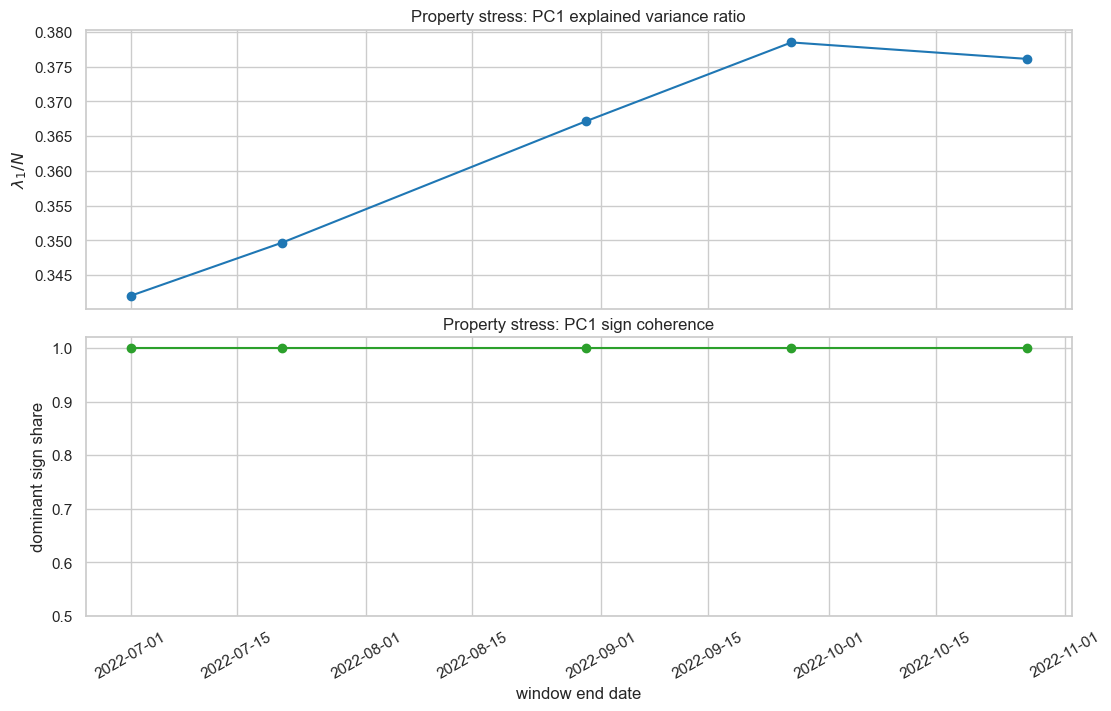

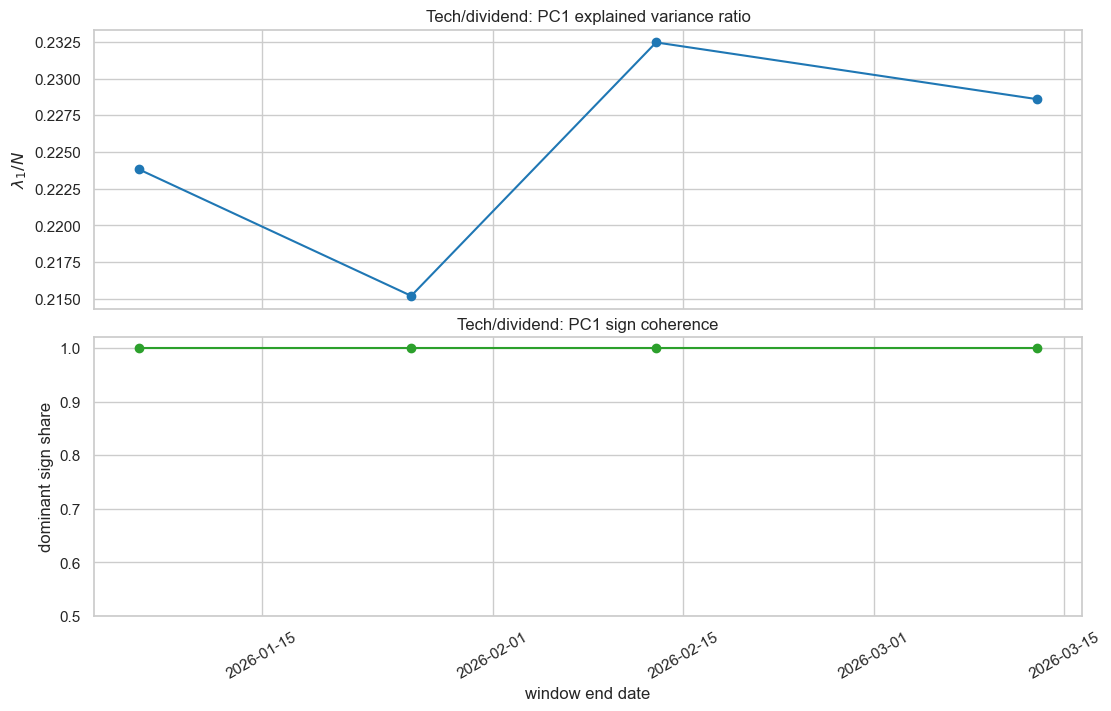

In [9]:
def plot_pc1_regime(regime_name: str):
    df = rolling_summary[rolling_summary["regime"] == regime_name].copy()
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, constrained_layout=True)

    axes[0].plot(df["window_end"], df["lambda1_over_N"], marker="o", color="tab:blue")
    axes[0].set_title(f"{regime_name}: PC1 explained variance ratio")
    axes[0].set_ylabel(r"$\lambda_1 / N$")

    axes[1].plot(df["window_end"], df["pc1_sign_coherence"], marker="o", color="tab:green")
    axes[1].set_title(f"{regime_name}: PC1 sign coherence")
    axes[1].set_ylabel("dominant sign share")
    axes[1].set_xlabel("window end date")
    axes[1].set_ylim(0.5, 1.02)

    for ax in axes:
        ax.tick_params(axis="x", rotation=30)
    plt.show()


for regime in REGIMES:
    plot_pc1_regime(regime)


### Experiment 1b: PC1 Score vs CSI 500 Return

If PC1 is really a market mode, then the time-series score obtained by projecting each day's standardized stock returns onto PC1 should move closely with the CSI 500 index return. For each rolling window, we compute

$$
s_t = X_t \widehat v_1,
$$

where $X_t$ is the standardized return vector in that window. Then we compare $s_t$ with the CSI 500 log return on the same dates. Since eigenvector signs are arbitrary, we report absolute correlation.


In [10]:
def fetch_index_close(index_code: str, start_date: str, end_date: str) -> pd.DataFrame:
    path = cache_path(f"index_daily_{index_code}_{start_date}_{end_date}.csv")
    if path.exists():
        return pd.read_csv(path, dtype={"trade_date": str})

    df = pro.index_daily(ts_code=index_code, start_date=start_date, end_date=end_date)
    if df.empty:
        raise ValueError(f"No index daily data for {index_code}, {start_date}-{end_date}.")
    out = df[["ts_code", "trade_date", "close"]].sort_values("trade_date")
    out.to_csv(path, index=False)
    time.sleep(0.08)
    return out


def index_log_returns_for_regime(index_code: str, start_date: str, end_date: str) -> pd.Series:
    close = fetch_index_close(index_code, start_date, end_date)
    close = close.copy()
    close["trade_date"] = pd.to_datetime(close["trade_date"])
    close = close.set_index("trade_date").sort_index()
    ret = np.log(close["close"]).diff().dropna()
    ret.name = "index_return"
    return ret


index_returns_by_regime = {
    regime_name: index_log_returns_for_regime(INDEX_CODE, start, end)
    for regime_name, (start, end) in REGIMES.items()
}


def pc1_score_index_corr_for_key(key) -> dict:
    regime_name, window_end = key
    res = rolling_details[key]["pca"]
    window_ret = rolling_details[key]["window_returns"].loc[:, res["columns"]]

    mu = window_ret.mean(axis=0)
    sigma = window_ret.std(axis=0, ddof=0)
    x = (window_ret - mu) / sigma

    pc1_score = pd.Series(x.to_numpy() @ res["eigvecs"][:, 0], index=x.index, name="pc1_score")
    index_ret = index_returns_by_regime[regime_name].reindex(pc1_score.index)
    aligned = pd.concat([pc1_score, index_ret], axis=1).dropna()

    corr = aligned["pc1_score"].corr(aligned["index_return"])
    return {
        "regime": regime_name,
        "window_end": window_end,
        "pc1_index_corr": corr,
        "abs_pc1_index_corr": abs(corr),
        "n_days_aligned": len(aligned),
    }


pc1_index_corr = pd.DataFrame([
    pc1_score_index_corr_for_key(key)
    for key in rolling_details
]).sort_values(["regime", "window_end"])

rolling_summary = rolling_summary.merge(
    pc1_index_corr[["regime", "window_end", "pc1_index_corr", "abs_pc1_index_corr", "n_days_aligned"]],
    on=["regime", "window_end"],
    how="left",
)

pc1_index_corr


,regime,window_end,pc1_index_corr,abs_pc1_index_corr,n_days_aligned
0,Property stress,2022-07-01,0.968546,0.968546,126
1,Property stress,2022-07-21,0.967920,0.967920,126
2,Property stress,2022-08-30,0.969935,0.969935,126
3,Property stress,2022-09-26,0.972269,0.972269,126
4,Property stress,2022-10-27,0.972011,0.972011,126
5,Tech/dividend,2026-01-06,0.873969,0.873969,126
6,Tech/dividend,2026-01-26,0.871221,0.871221,126
7,Tech/dividend,2026-02-13,0.871236,0.871236,126
8,Tech/dividend,2026-03-13,0.875983,0.875983,126


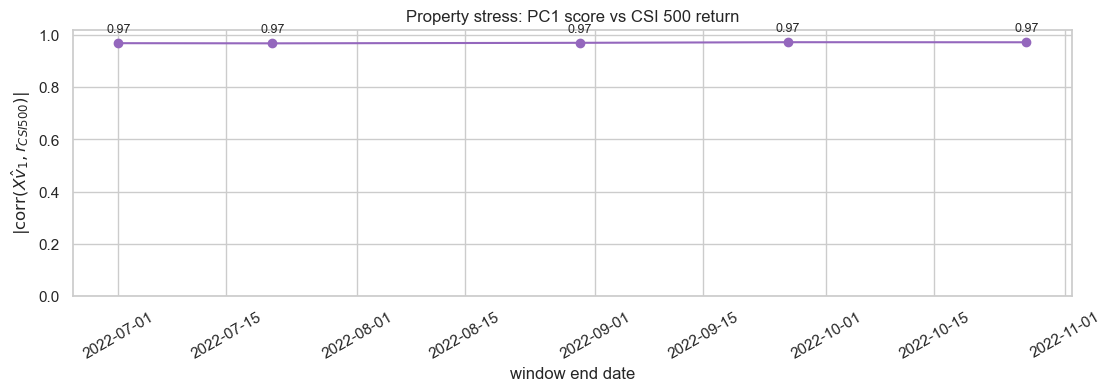

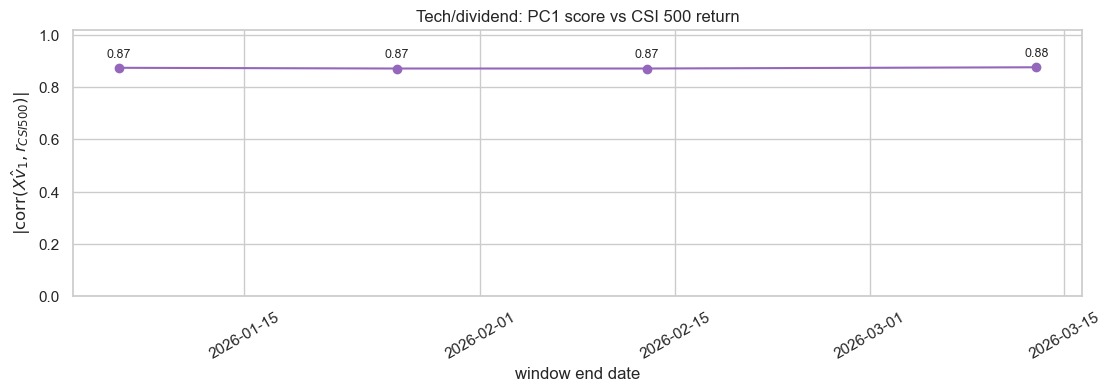

In [11]:
def plot_pc1_index_corr_regime(regime_name: str):
    df = pc1_index_corr[pc1_index_corr["regime"] == regime_name].copy()
    fig, ax = plt.subplots(figsize=(11, 3.8), constrained_layout=True)

    ax.plot(df["window_end"], df["abs_pc1_index_corr"], marker="o", color="tab:purple")
    ax.set_title(f"{regime_name}: PC1 score vs CSI 500 return")
    ax.set_ylabel(r"$|\mathrm{corr}(X\hat v_1, r_{CSI500})|$")
    ax.set_xlabel("window end date")
    ax.set_ylim(0, 1.02)
    ax.tick_params(axis="x", rotation=30)

    for _, row in df.iterrows():
        ax.text(row["window_end"], row["abs_pc1_index_corr"] + 0.03, f"{row['abs_pc1_index_corr']:.2f}",
                ha="center", va="bottom", fontsize=9)
    plt.show()


for regime in REGIMES:
    plot_pc1_index_corr_regime(regime)


**Interpretation.**

The high correlation between the PC1 score and CSI 500 index return means that the market's movement intensity along the PC1 direction is strongly related to the movement of the market index. In other words, PC1 is not merely a mathematical top-eigenvector: it works as a good indicator of market co-movement in these rolling windows.

We should still be careful with wording: PC1 does not detect price trend directly. It detects the dominant common return direction across stocks, and the diagnostic above shows that this dominant co-movement direction is highly aligned with the CSI 500 market return.


### Experiment 1c: PC1 Sector-Average Loading Check

Since PC1 works as a market co-movement direction, we now inspect which SW2021 first-level sectors have larger or smaller average exposure to PC1. Instead of only looking at a few top-loading stocks, we compute the average signed PC1 loading across all stocks inside each sector.

For each sector, the table also reports the number of stocks in that sector. To avoid unstable rankings driven by sectors with only a few stocks, we only include sectors with at least 5 stocks in the final top/bottom ranking. We focus on the top 5 sectors and bottom 3 sectors by average PC1 loading.


In [12]:
MIN_SECTOR_STOCKS = 5


def pc1_sector_average_loading_table(key) -> pd.DataFrame:
    regime_name, window_end = key
    res = rolling_details[key]["pca"]
    columns = res["columns"]
    vec = res["eigvecs"][:, 0]

    df = pd.DataFrame({
        "ts_code": columns,
        "sector": sector_final.reindex(columns).values,
        "pc1_loading": vec,
    }).dropna(subset=["sector"])

    out = (
        df.groupby("sector")
        .agg(
            avg_pc1_loading=("pc1_loading", "mean"),
            avg_abs_pc1_loading=("pc1_loading", lambda x: x.abs().mean()),
            n_stocks=("ts_code", "count"),
        )
        .reset_index()
        .sort_values("avg_pc1_loading", ascending=False)
    )
    out.insert(0, "regime", regime_name)
    out.insert(1, "window_end", window_end)
    return out


def sector_loading_extremes(table: pd.DataFrame, top_n: int = 5, bottom_n: int = 3) -> pd.DataFrame:
    table = table[table["n_stocks"] >= MIN_SECTOR_STOCKS].copy()
    top = table.nlargest(top_n, "avg_pc1_loading").copy()
    top["group"] = "top"
    top["rank"] = range(1, len(top) + 1)

    bottom = table.nsmallest(bottom_n, "avg_pc1_loading").copy()
    bottom["group"] = "bottom"
    bottom["rank"] = range(1, len(bottom) + 1)

    return pd.concat([top, bottom], ignore_index=True)[[
        "regime", "group", "rank", "sector",
        "avg_pc1_loading", "avg_abs_pc1_loading", "n_stocks"
    ]]


pc1_sector_loading_all = pd.concat([
    pc1_sector_average_loading_table(key)
    for key in rolling_details
], ignore_index=True)

pc1_sector_loading_regime = (
    pc1_sector_loading_all
    .groupby(["regime", "sector"])
    .agg(
        avg_pc1_loading=("avg_pc1_loading", "mean"),
        avg_abs_pc1_loading=("avg_abs_pc1_loading", "mean"),
        n_stocks=("n_stocks", "median"),
    )
    .reset_index()
)

pc1_sector_loading_regime_extremes = pd.concat([
    sector_loading_extremes(group, top_n=5, bottom_n=3)
    for _, group in pc1_sector_loading_regime.groupby("regime")
], ignore_index=True)

pc1_sector_loading_regime_extremes.round(4)


,regime,group,rank,sector,avg_pc1_loading,avg_abs_pc1_loading,n_stocks
0,Property stress,top,1,非银金融,0.0789,0.0789,16.0
1,Property stress,top,2,环保,0.0740,0.0740,6.0
2,Property stress,top,3,传媒,0.0738,0.0738,9.0
3,Property stress,top,4,银行,0.0729,0.0729,6.0
4,Property stress,top,5,交通运输,0.0689,0.0689,9.0
5,Property stress,bottom,1,煤炭,0.0531,0.0531,5.0
6,Property stress,bottom,2,医药生物,0.0539,0.0539,20.0
7,Property stress,bottom,3,国防军工,0.0548,0.0548,13.0
8,Tech/dividend,top,1,非银金融,0.0868,0.0868,16.0
9,Tech/dividend,top,2,有色金属,0.0793,0.0793,11.0


### Regime Summary Table

This table compresses rolling-window results into regime-level diagnostics.


In [13]:
regime_table = (
    rolling_summary
    .groupby("regime")
    .agg(
        windows=("window_end", "count"),
        N=("N", "median"),
        mean_lambda1_over_N=("lambda1_over_N", "mean"),
        median_lambda1_over_N=("lambda1_over_N", "median"),
        mean_sign_coherence=("pc1_sign_coherence", "mean"),
        mean_abs_pc1_index_corr=("abs_pc1_index_corr", "mean"),
    )
    .round(3)
)
regime_table


,windows,N,mean_lambda1_over_N,median_lambda1_over_N,mean_sign_coherence,mean_abs_pc1_index_corr
regime,,,,,,
Property stress,5,229.0,0.363,0.367,1.0,0.970
Tech/dividend,4,229.0,0.225,0.226,1.0,0.873


## Interpretation Notes

Careful wording:

- `lambda_1 / N` is PC1 explained variance ratio for standardized returns. It is interpreted as market-mode strength only together with high sign coherence.
- The PC1 score vs CSI 500 return diagnostic checks whether the dominant common return direction is economically aligned with a broad market index.
- PC1 is not a price-trend detector. It measures the dominant co-movement direction across stocks, and the high score-index correlation suggests this direction is a useful market-mode indicator.
- Sector-average PC1 loading gives a regime-level view of which industries have higher or lower exposure to this common market-mode direction. We filter sectors with fewer than 5 stocks to avoid unstable rankings.
